<a href="https://colab.research.google.com/github/Pritam7421/Customer_churn_Analysis/blob/main/Customer_churn_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

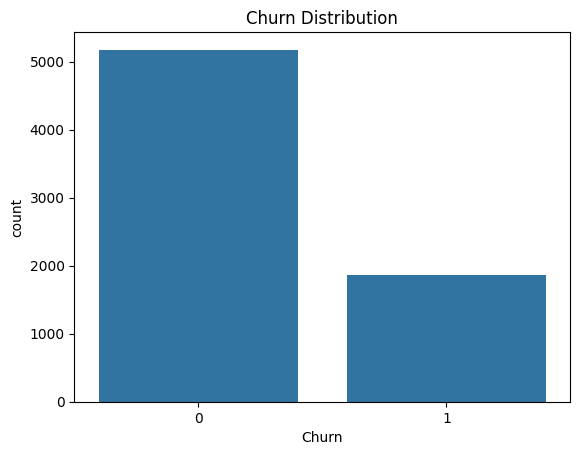

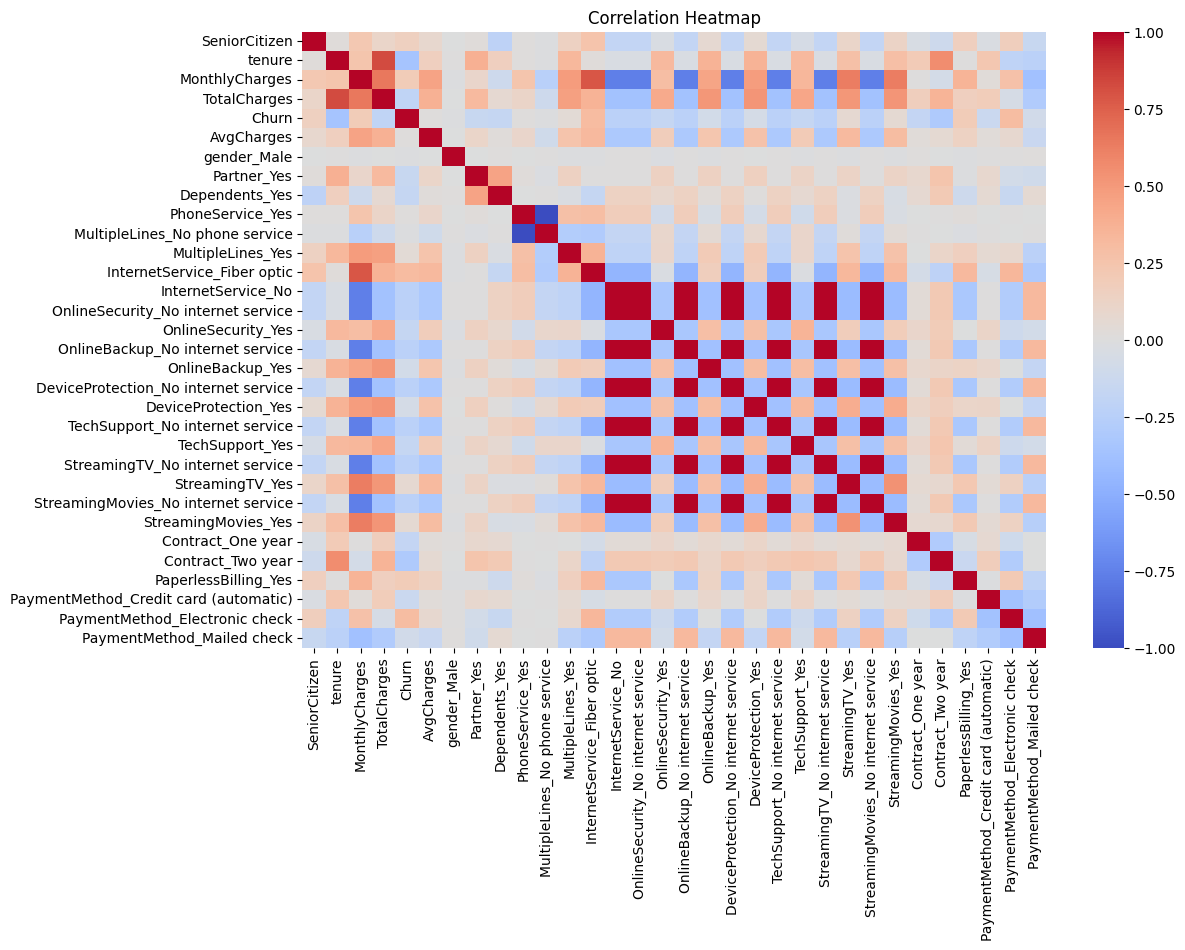

🔹 Logistic Regression Accuracy: 0.8119233498935415
              precision    recall  f1-score   support

           0       0.85      0.90      0.88      1036
           1       0.67      0.56      0.61       373

    accuracy                           0.81      1409
   macro avg       0.76      0.73      0.74      1409
weighted avg       0.80      0.81      0.81      1409

🔹 Random Forest Accuracy: 0.7963094393186657
              precision    recall  f1-score   support

           0       0.83      0.90      0.87      1036
           1       0.65      0.50      0.56       373

    accuracy                           0.80      1409
   macro avg       0.74      0.70      0.72      1409
weighted avg       0.78      0.80      0.79      1409



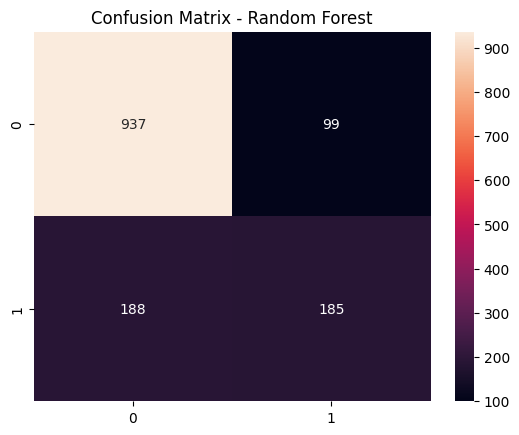

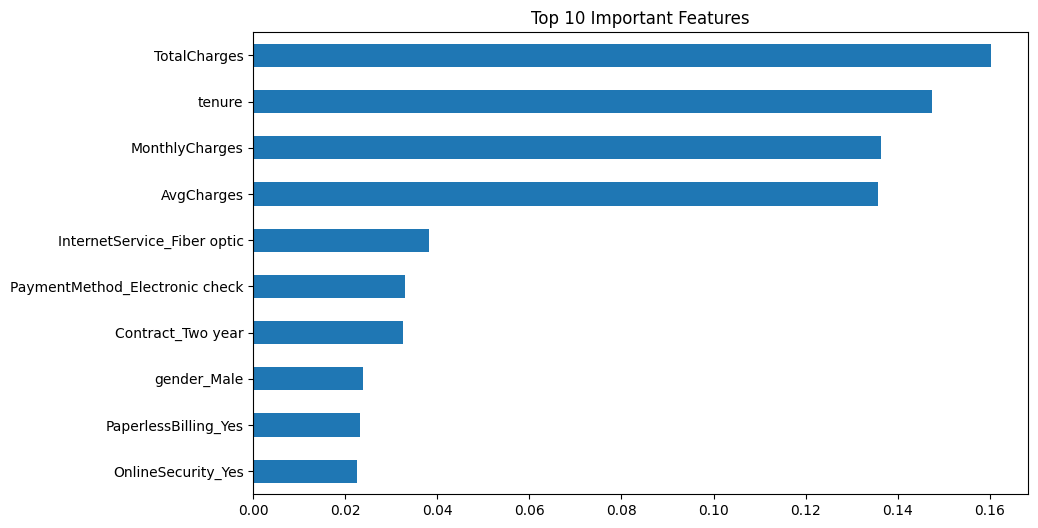


📊 KEY INSIGHTS:
- Month-to-month contract customers are more likely to churn
- Customers with low tenure are high risk
- Higher monthly charges increase churn probability
- Lack of tech support/security increases churn


In [4]:
# ===============================
# 1. IMPORT LIBRARIES
# ===============================
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ===============================
# 2. LOAD DATA
# ===============================
df = pd.read_csv('/content/Telco-Customer-Churn.csv')

# ===============================
# 3. DATA CLEANING
# ===============================
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())
df = df.drop('customerID', axis=1, errors='ignore')

# ===============================
# 4. FEATURE ENGINEERING
# ===============================
df['AvgCharges'] = df['TotalCharges'] / (df['tenure'] + 1)

# ===============================
# 5. ENCODING
# ===============================
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
df = pd.get_dummies(df, drop_first=True)

# ===============================
# 6. EDA
# ===============================
sns.countplot(x='Churn', data=df)
plt.title("Churn Distribution")
plt.show()

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# ===============================
# 7. TRAIN-TEST SPLIT
# ===============================
X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ===============================
# 8. SCALING
# ===============================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ===============================
# 9. LOGISTIC REGRESSION
# ===============================
lr = LogisticRegression(max_iter=5000, solver='liblinear')
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

print("🔹 Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

# ===============================
# 10. RANDOM FOREST
# ===============================
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("🔹 Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

# ===============================
# 11. CONFUSION MATRIX
# ===============================
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d')
plt.title("Confusion Matrix - Random Forest")
plt.show()

# ===============================
# 12. FEATURE IMPORTANCE
# ===============================
importance = pd.Series(rf.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=False)

plt.figure(figsize=(10,6))
importance.head(10).plot(kind='barh')
plt.title("Top 10 Important Features")
plt.gca().invert_yaxis()
plt.show()

# ===============================
# 13. FINAL INSIGHTS PRINT
# ===============================
print("\n📊 KEY INSIGHTS:")
print("- Month-to-month contract customers are more likely to churn")
print("- Customers with low tenure are high risk")
print("- Higher monthly charges increase churn probability")
print("- Lack of tech support/security increases churn")